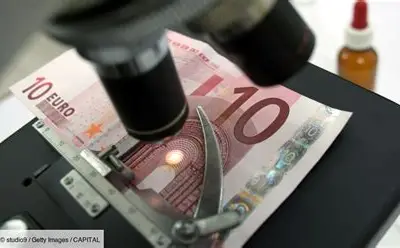<div style="display: flex; background-color: RGB(128,0,0);" >
<h1 style="margin: auto; padding: 30px; "> FAUX BILLETS V2
 </h1>
</div>

In [ ]:
#declarer le drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# exploration data
import pandas as pd
import numpy as np

# viz
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pickle

In [ ]:

#!pip install sklearn

#!pip install matplotlib seaborn scip

In [ ]:

!pip install statsmodels
#.api as sm

In [ ]:

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [ ]:
#!pip install pandas numpy matplotlib seaborn scipy


In [ ]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from scipy.stats import chi2

In [ ]:

#bil = pd.read_csv(r"C:\Users\dchan\Downloads\P12OPC\billets.csv", sep=";")
bil = pd.read_csv("/content/drive/My Drive/Colab Notebooks/P12_OPC/billets.csv", sep=";")
#"C:\Users\dchan\Downloads\P12OPC\billets.csv"
display(bil)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


#####1. Prise en main et exploration des données

1.1 Aperçu & info

In [ ]:
# Afficher les premières lignes et infos de base
print(bil.head())

   is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
0        True    171.81       104.86        104.95        4.52       2.89   
1        True    171.46       103.36        103.66        3.77       2.99   
2        True    172.69       104.48        103.50        4.40       2.94   
3        True    171.36       103.91        103.94        3.62       3.01   
4        True    171.73       104.28        103.46        4.04       3.48   

   length  
0  112.83  
1  113.09  
2  113.16  
3  113.51  
4  112.54  


In [ ]:
print("\nInfo:")
print(bil.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
None


In [ ]:
print("\nDescriptions rapides (count, mean, std, min, max):")
print(bil.describe().T)


Descriptions rapides (count, mean, std, min, max):
               count        mean       std     min      25%     50%     75%  \
diagonal      1500.0  171.958440  0.305195  171.04  171.750  171.96  172.17   
height_left   1500.0  104.029533  0.299462  103.14  103.820  104.04  104.23   
height_right  1500.0  103.920307  0.325627  102.82  103.710  103.92  104.15   
margin_low    1463.0    4.485967  0.663813    2.98    4.015    4.31    4.87   
margin_up     1500.0    3.151473  0.231813    2.27    2.990    3.14    3.31   
length        1500.0  112.678500  0.872730  109.49  112.030  112.96  113.34   

                 max  
diagonal      173.01  
height_left   104.88  
height_right  104.95  
margin_low      6.90  
margin_up       3.91  
length        114.44  


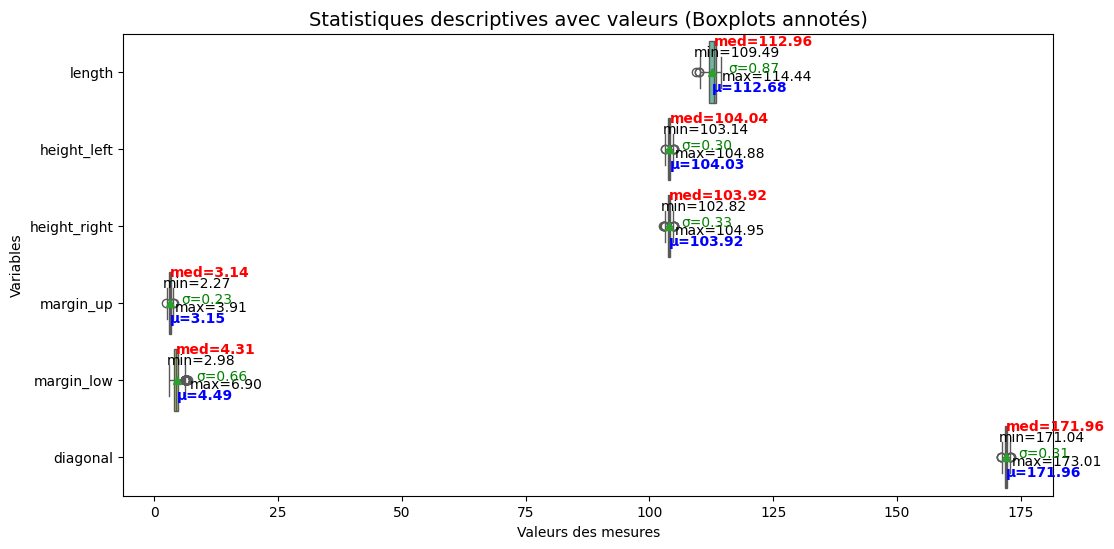

In [ ]:
vars_numeriques = ["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]

plt.figure(figsize=(12,6))
ax = sns.boxplot(data=bil[vars_numeriques], orient="h", palette="Set2", showmeans=True)

# Boucle sur chaque variable pour annoter les valeurs
for i, var in enumerate(vars_numeriques):
    col = bil[var].dropna()
    mean = np.mean(col)
    median = np.median(col)
    min_val = np.min(col)
    max_val = np.max(col)
    std = np.std(col)

    # Position verticale (même que la box correspondante)
    y = i

    # On place les textes à côté des boxplots
    ax.text(max_val + 0.2, y + 0.1, f"max={max_val:.2f}", color="black")
    ax.text(min_val - 0.5, y - 0.2, f"min={min_val:.2f}", color="black")
    ax.text(mean, y + 0.25, f"µ={mean:.2f}", color="blue", weight="bold")
    ax.text(median, y - 0.35, f"med={median:.2f}", color="red", weight="bold")
    ax.text(max_val + 1.5, y, f"σ={std:.2f}", color="green")

plt.title("Statistiques descriptives avec valeurs (Boxplots annotés)", fontsize=14)
plt.xlabel("Valeurs des mesures")
plt.ylabel("Variables")
plt.show()


####1.2 Répartition billets vrais/faux

Counts:
 is_genuine
True     1000
False     500
Name: count, dtype: int64


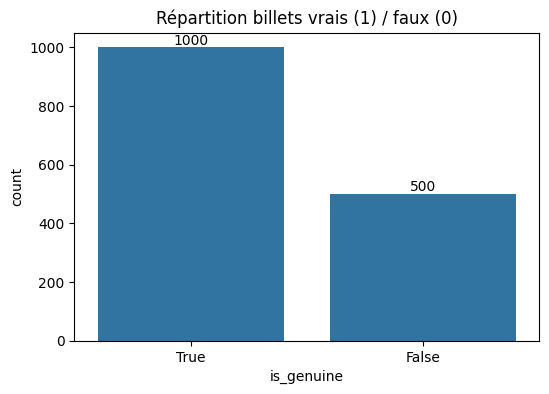

In [ ]:
# Compter is_genuine (vrais vs faux) et visualiser
counts = bil['is_genuine'].value_counts()
print("Counts:\n", counts)

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.xlabel('is_genuine')
plt.ylabel('count')
plt.title('Répartition billets vrais (1) / faux (0)')
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, str(v), ha='center')
plt.show()


In [ ]:
#penser à remplir les manquants avec la regression ; faire la classification après avoir rein
"""matrice de coor  pour chaque algo
acp
regression log
kmeans

knnrandom forest

"""""

'matrice de coor  pour chaque algo\nacp\nregression log\nkmeans\n\nknnrandom forest\n\n'

In [ ]:
# Vérifier la proportion attendue (ex: 1000 vs 500)
print("Proportions:\n", (counts / counts.sum()).round(3))

Proportions:
 is_genuine
True     0.667
False    0.333
Name: count, dtype: float64


####1.3 Statistiques descriptives détaillées

In [ ]:
# Stats demandées: moyenne, médiane, min, max, std par variable
numerical = ['diagonal','height_left','height_right','margin_low','margin_up','length']
desc = bil[numerical].agg(['count','mean','median','std','min','max']).T
print(desc)


               count        mean  median       std     min     max
diagonal      1500.0  171.958440  171.96  0.305195  171.04  173.01
height_left   1500.0  104.029533  104.04  0.299462  103.14  104.88
height_right  1500.0  103.920307  103.92  0.325627  102.82  104.95
margin_low    1463.0    4.485967    4.31  0.663813    2.98    6.90
margin_up     1500.0    3.151473    3.14  0.231813    2.27    3.91
length        1500.0  112.678500  112.96  0.872730  109.49  114.44


(array([1, 2]), [Text(1, 0, 'margin_up'), Text(2, 0, 'margin_low')])

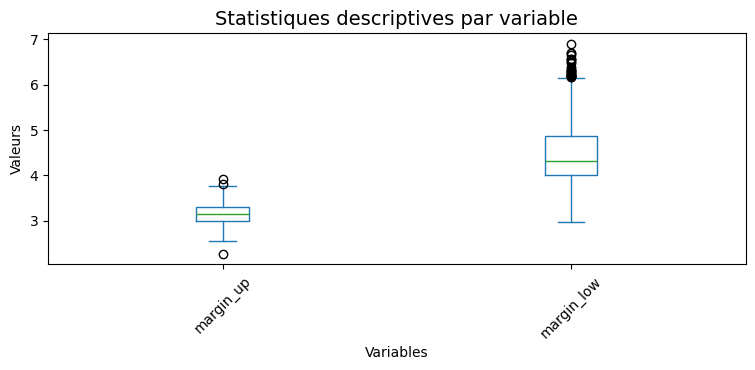

In [ ]:
bil[['margin_up', 'margin_low']].plot(kind='box', figsize=(9,3))
plt.title("Statistiques descriptives par variable", fontsize=14)
plt.ylabel("Valeurs")
plt.xlabel("Variables")
plt.xticks(rotation=45)
#pareil

(array([1, 2]), [Text(1, 0, 'height_left'), Text(2, 0, 'height_right')])

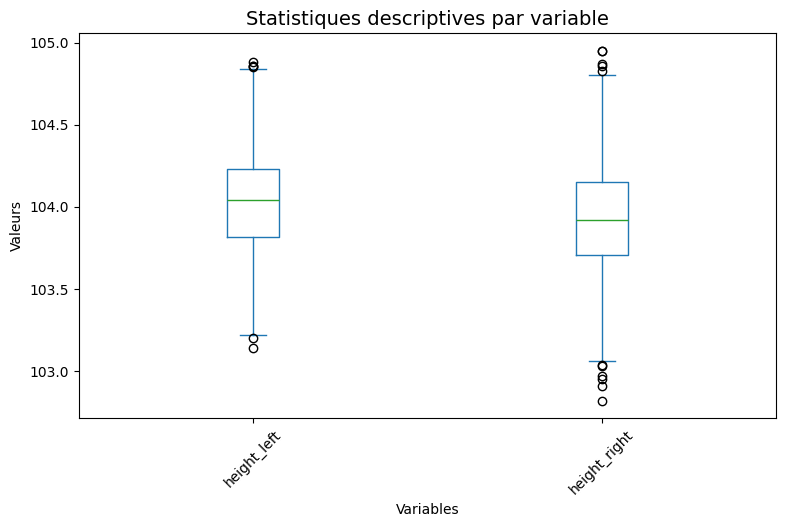

In [ ]:
bil[['height_left','height_right']].plot(kind='box', figsize=(9,5))
plt.title("Statistiques descriptives par variable", fontsize=14)
plt.ylabel("Valeurs")
plt.xlabel("Variables")
plt.xticks(rotation=45)

(array([1, 2]), [Text(1, 0, 'margin_up'), Text(2, 0, 'length')])

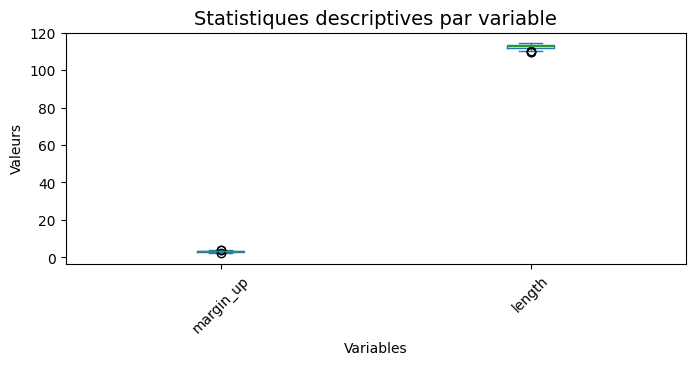

In [ ]:
bil[['margin_up','length']].plot(kind='box', figsize=(8,3))
plt.title("Statistiques descriptives par variable", fontsize=14)
plt.ylabel("Valeurs")
plt.xlabel("Variables")
plt.xticks(rotation=45)

####1.4 Distributions & boxplots

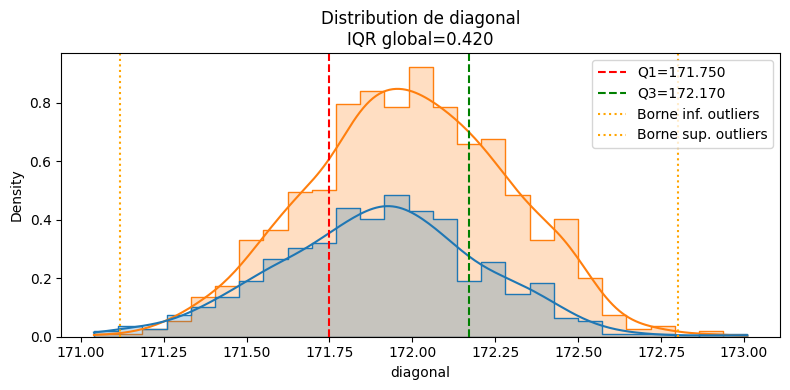

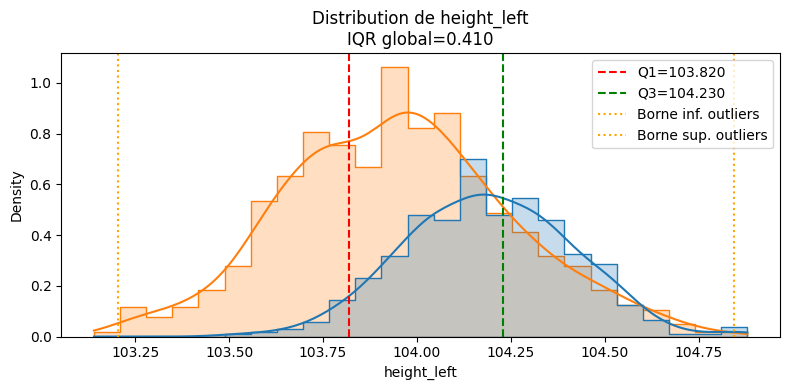

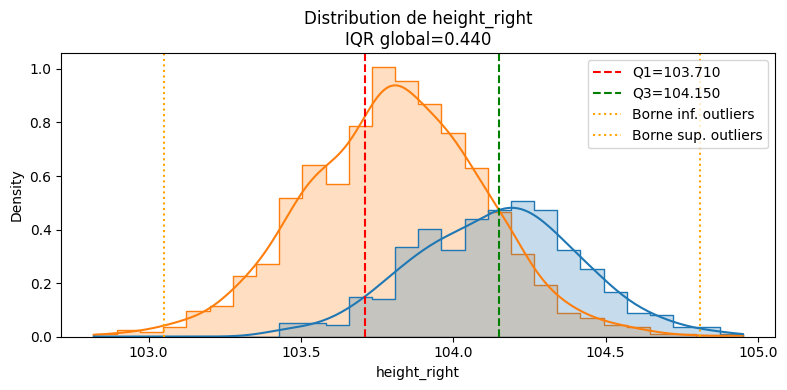

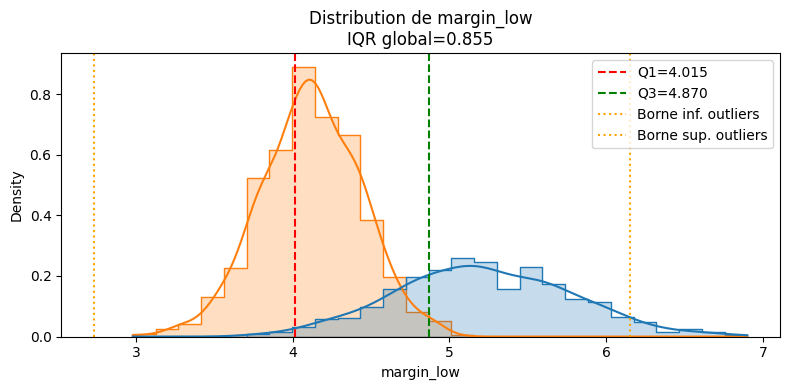

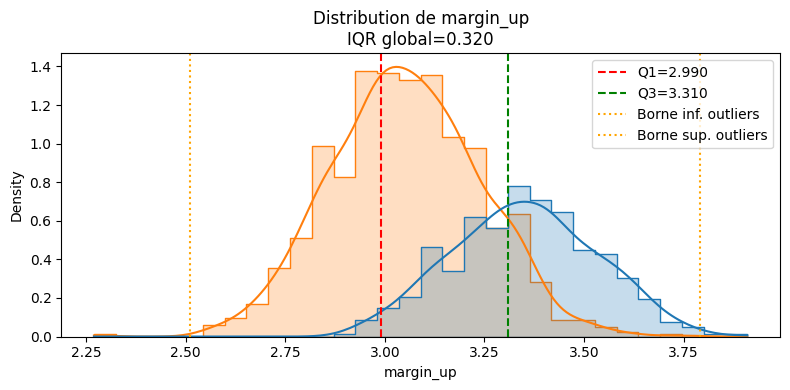

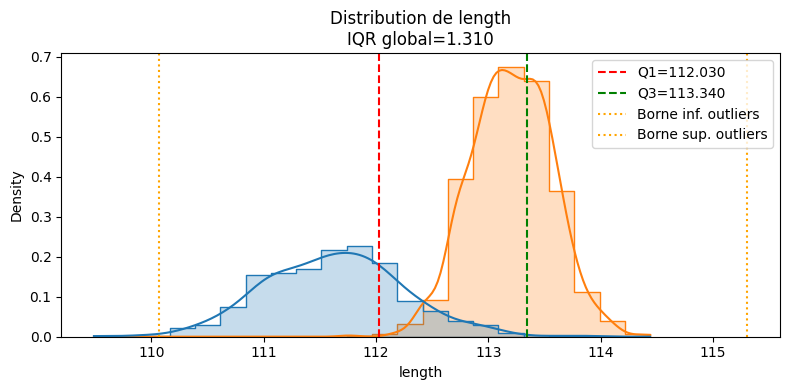

In [ ]:
# Histogrammes / KDE par feature avec is_genuine (True/False) + IQR
cols = bil.select_dtypes(include="number").columns

for c in cols:
    plt.figure(figsize=(8, 4))

    # Histogramme avec KDE et séparation par is_genuine
    sns.histplot(data=bil, x=c, hue="is_genuine", kde=True, stat="density", element="step")

    # Calcul Q1, Q3, IQR global
    q1 = bil[c].quantile(0.25)
    q3 = bil[c].quantile(0.75)
    iqr = q3 - q1

    #  repères
    plt.axvline(q1, color="red", linestyle="--", label=f"Q1={q1:.3f}")
    plt.axvline(q3, color="green", linestyle="--", label=f"Q3={q3:.3f}")
    plt.axvline(q1 - 1.5*iqr, color="orange", linestyle=":", label="Borne inf. outliers")
    plt.axvline(q3 + 1.5*iqr, color="orange", linestyle=":", label="Borne sup. outliers")

    plt.title(f"Distribution de {c}\nIQR global={iqr:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()


####1.5 Détection d’outliers univariés (IQR & z-score)

Nombre de lignes contenant au moins un outlier (IQR): 53
Nombre outliers (z-score > 3): 23
Nombre de lignes détectées par les deux méthodes: 23


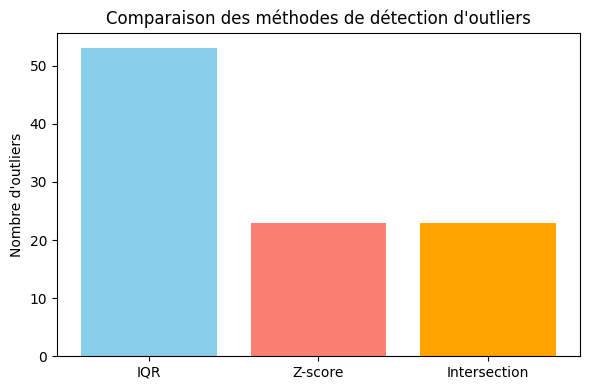

In [ ]:


#  Détection des outliers IQR
outlier_indices = set()
for c in numerical:
    q1 = bil[c].quantile(0.25)
    q3 = bil[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    inds = bil[(bil[c] < lower) | (bil[c] > upper)].index
    outlier_indices.update(inds)

iqr_outliers = set(outlier_indices)

# Détection des outliers Z-score
z = np.abs(stats.zscore(bil[numerical].dropna()))
z_outliers = bil[numerical].dropna()[(z > 3).any(axis=1)].index
z_outliers = set(z_outliers)

# --- Comptages ---
n_iqr = len(iqr_outliers)
n_z = len(z_outliers)
n_both = len(iqr_outliers & z_outliers)

print("Nombre de lignes contenant au moins un outlier (IQR):", n_iqr)
print("Nombre outliers (z-score > 3):", n_z)
print("Nombre de lignes détectées par les deux méthodes:", n_both)

# --- Barplot comparatif ---
plt.figure(figsize=(6,4))
plt.bar(["IQR", "Z-score", "Intersection"], [n_iqr, n_z, n_both], color=["skyblue", "salmon", "orange"])
plt.ylabel("Nombre d'outliers")
plt.title("Comparaison des méthodes de détection d'outliers")
plt.tight_layout()
plt.show()



In [ ]:
# IQR-based outliers
outlier_indices = set()
for c in numerical:
    q1 = bil[c].quantile(0.25)
    q3 = bil[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    inds = bil[(bil[c] < lower) | (bil[c] > upper)].index
    outlier_indices.update(inds)

print("Nombre de lignes contenant au moins un outlier (IQR):", len(outlier_indices))
print("Exemples d'indices outliers:", list(outlier_indices)[:20])

Nombre de lignes contenant au moins un outlier (IQR): 53
Exemples d'indices outliers: [0, 1027, 1029, 1031, 522, 1290, 1420, 1041, 1169, 1426, 1022, 664, 1053, 1441, 292, 1321, 1322, 1453, 1199, 176]


In [ ]:


# z-score > 3 method
z = np.abs(stats.zscore(bil[numerical].dropna()))
z_outliers = bil[numerical].dropna()[(z > 3).any(axis=1)]
print("Nombre outliers (z-score > 3):", z_outliers.shape[0])


Nombre outliers (z-score > 3): 23


/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


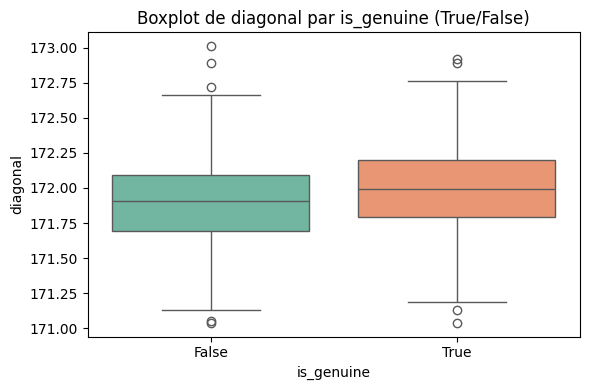

/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


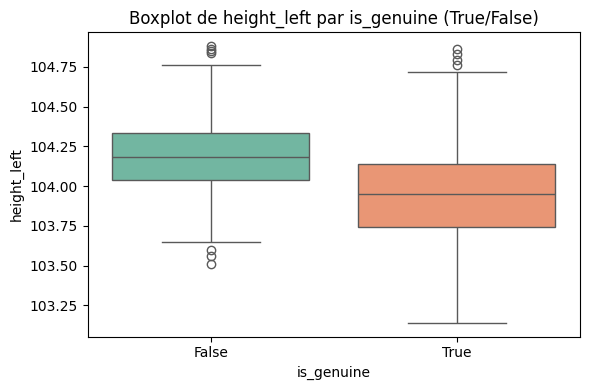

/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


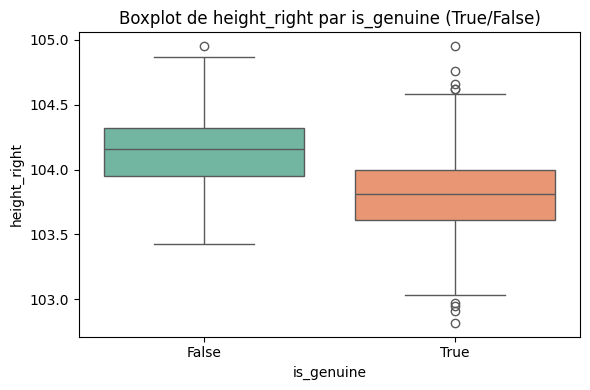

/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


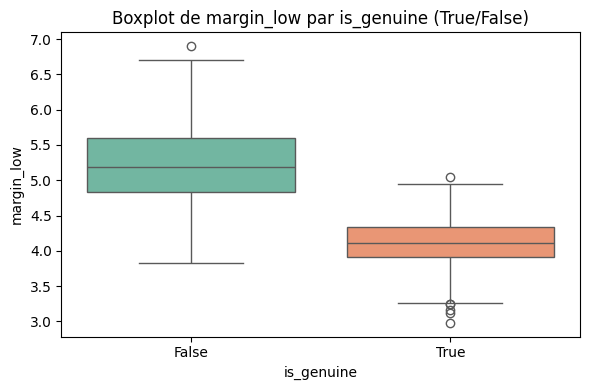

/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


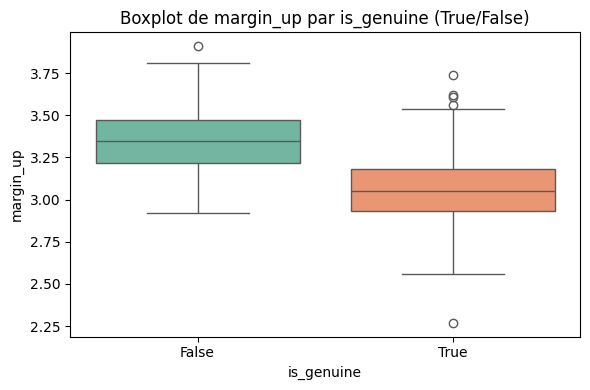

/tmp/ipython-input-3707731089.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")


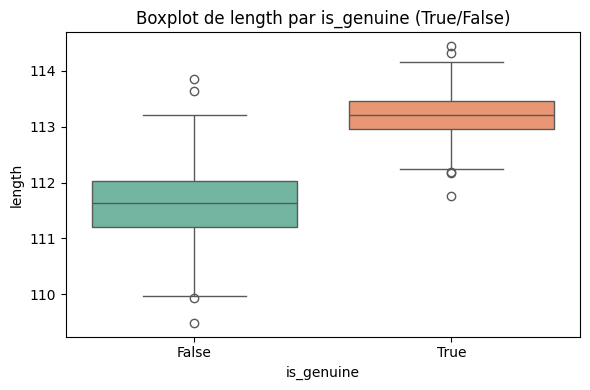

In [ ]:
# 'is_genuine'  variable cible
label_col = "is_genuine"

# toutes les colonnes numériques sauf la cible
cols = bil.select_dtypes(include="number").columns.drop(label_col, errors="ignore")

# Boxplots comparatifs
for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=label_col, y=c, data=bil, palette="Set2")
    plt.title(f"Boxplot de {c} par {label_col} (True/False)")
    plt.tight_layout()
    plt.show()




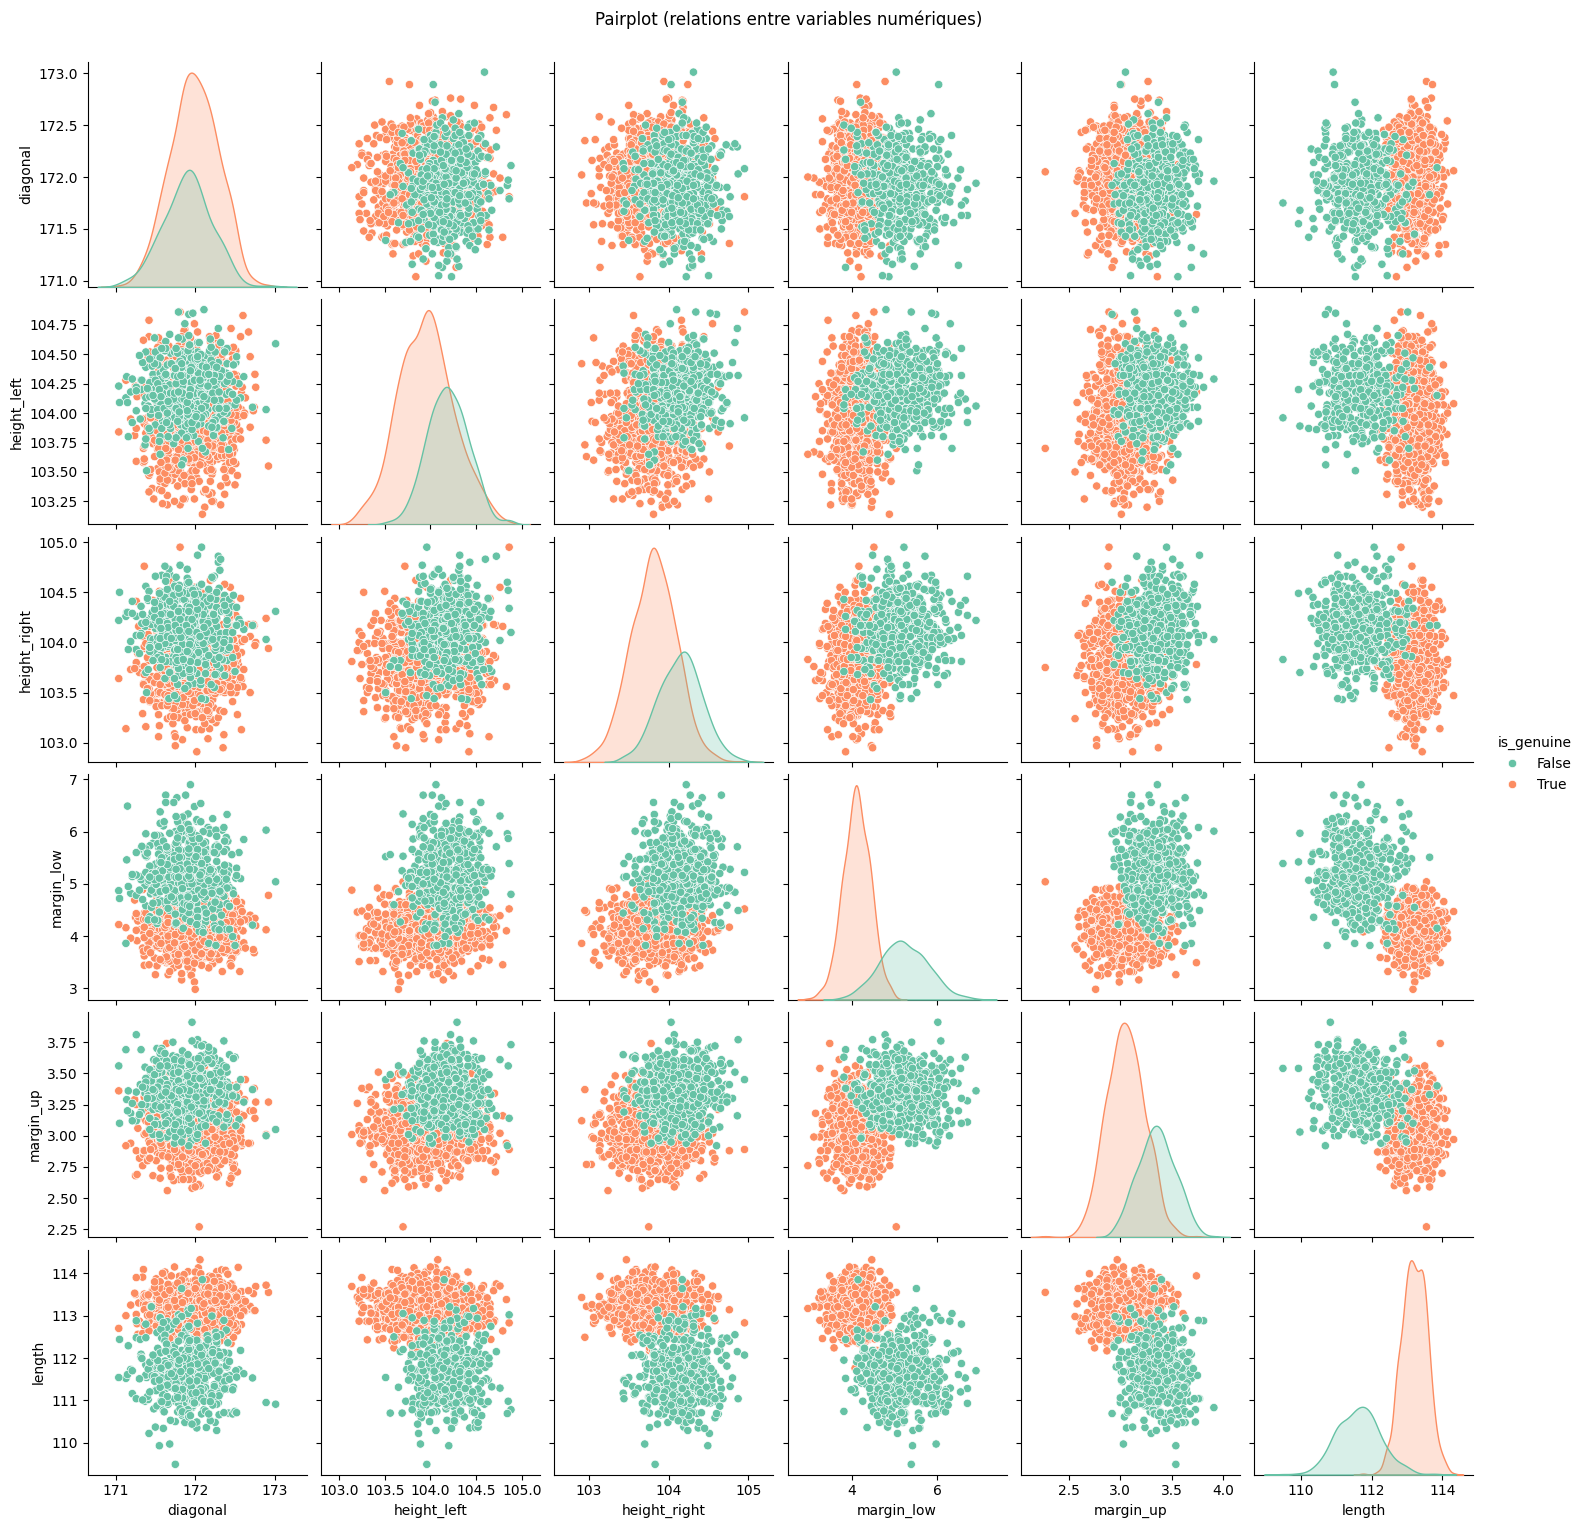

In [ ]:
# Pairplot (comparaison globale)
if len(cols) <= 6:  # je peux exclure certaines var
    sns.pairplot(bil[cols.tolist() + [label_col]].dropna(), hue=label_col, palette="Set2")
    plt.suptitle("Pairplot (relations entre variables numériques)", y=1.02)
    plt.show()

In [ ]:

# --- Configuration ---
label_col = "is_genuine"

# Colonnes numériques à analyser (exclure la variable cible)
cols = bil.select_dtypes(include="number").columns.drop(label_col, errors="ignore")


=== Statistiques descriptives (global) ===


,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44



=== Statistiques descriptives par classe ===


is_genuine                False        True 
diagonal     count   500.000000  1000.000000
             mean    171.901160   171.987080
             median  171.910000   171.990000
             min     171.040000   171.040000
             max     173.010000   172.920000
             std       0.306861     0.300441
height_left  count   500.000000  1000.000000
             mean    104.190340   103.949130
             median  104.180000   103.950000
             min     103.510000   103.140000
             max     104.880000   104.860000
             std       0.223758     0.300231
height_right count   500.000000  1000.000000
             mean    104.143620   103.808650
             median  104.160000   103.810000
             min     103.430000   102.820000
             max     104.950000   104.950000
             std       0.270878     0.291570
margin_low   count   492.000000   971.000000
             mean      5.215935     4.116097
             median    5.190000     4.110000
             min       3.820000     2.980000
             max       6.900000     5.040000
             std       0.553531     0.319124
margin_up    count   500.000000  1000.000000
             mean      3.350160     3.052130
             median    3.350000     3.050000
             min       2.920000     2.270000
             max       3.910000     3.740000
             std       0.180498     0.186340
length       count   500.000000  1000.000000
             mean    111.630640   113.202430
             median  111.630000   113.205000
             min     109.490000   111.760000
             max     113.850000   114.440000
             std       0.615543     0.359552

<Figure size 1200x600 with 0 Axes>

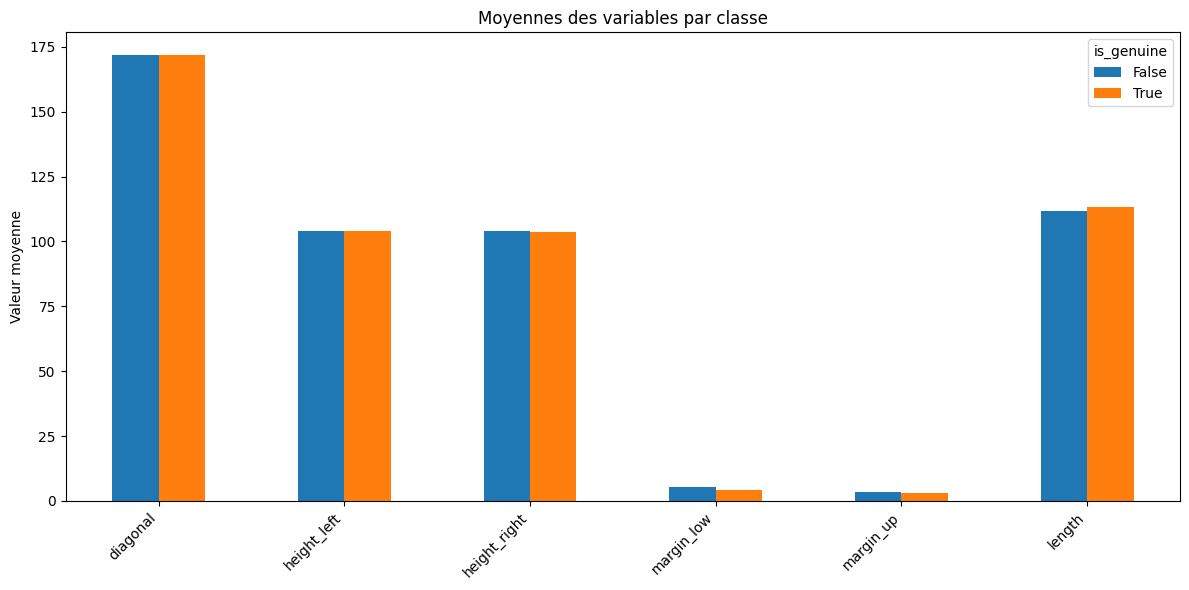

<Figure size 1200x600 with 0 Axes>

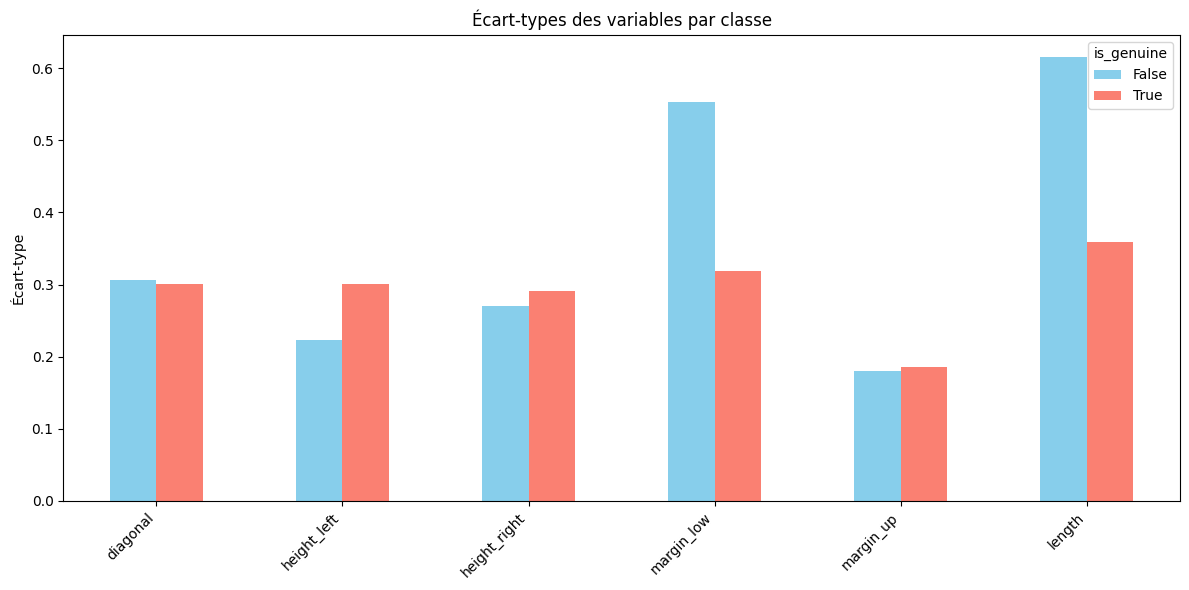

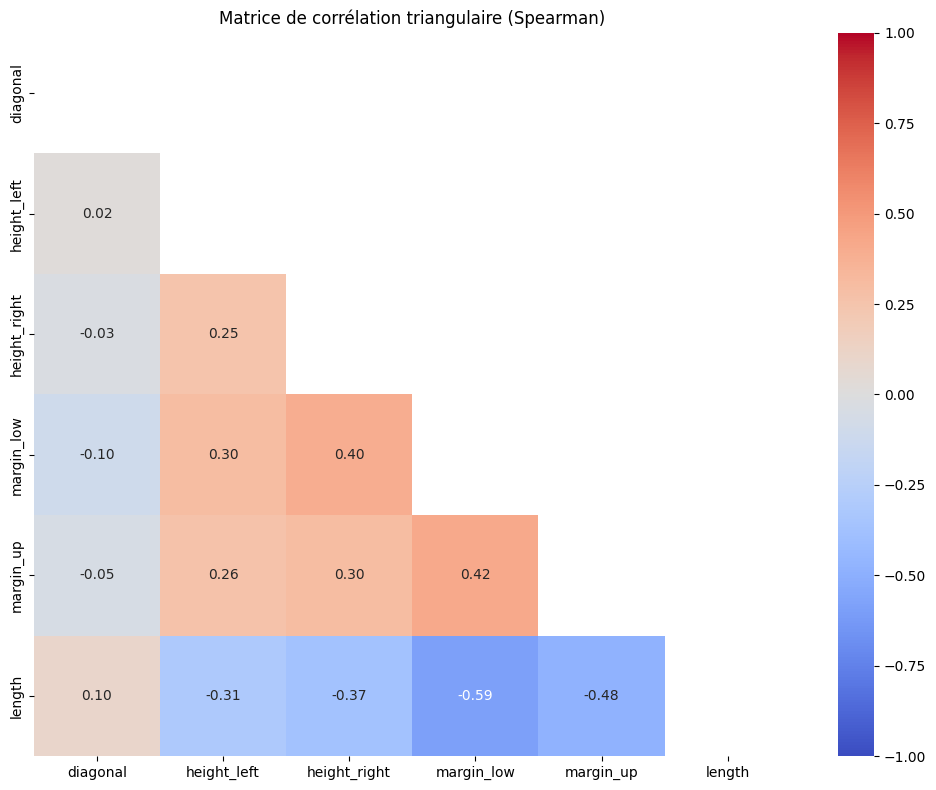

In [ ]:
# 1) Statistiques descriptives


print("\n=== Statistiques descriptives (global) ===")
display(bil[cols].describe().T)

if label_col:
    print("\n=== Statistiques descriptives par classe ===")
    stats_by_class = bil.groupby(label_col)[cols].agg(['count','mean','median','min','max','std']).T
    display(stats_by_class)
      # --- Graphique : Moyennes par classe ---
    means = bil.groupby(label_col)[cols].mean().T
    plt.figure(figsize=(12,6))
    means.plot(kind="bar", figsize=(12,6))
    plt.title("Moyennes des variables par classe")
    plt.ylabel("Valeur moyenne")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



     #Graphique : Écart-types par classe
    stds = bil.groupby(label_col)[cols].std().T
    plt.figure(figsize=(12,6))
    stds.plot(kind="bar", figsize=(12,6), color=["skyblue","salmon"])
    plt.title("Écart-types des variables par classe")
    plt.ylabel("Écart-type")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()




# 2) Matrice de corrélation triangulaire (Spearman)


corr = bil[cols].corr(method="spearman")

# Masque triangulaire supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Matrice de corrélation triangulaire (Spearman)")
plt.tight_layout()
plt.show()

# 3) Identifier fortes corrélations

# Seuils pour corrélation forte
strong_pos = 0.6
strong_neg = -0.6

strong_corr = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i,j]
        if val >= strong_pos or val <= strong_neg:
            strong_corr.append((corr.index[i], corr.columns[j], val))

In [ ]:
# 1) Extraire toutes les corrélations hors diagonale
corr_list = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        corr_list.append((corr.index[i], corr.columns[j], val))

# 2) Créer un DataFrame et trier par force (valeur absolue)
corr_df = pd.DataFrame(corr_list, columns=["Variable 1", "Variable 2", "Corrélation"])
corr_df["AbsCorr"] = corr_df["Corrélation"].abs()
corr_df = corr_df.sort_values(by="AbsCorr", ascending=False).reset_index(drop=True)

display(corr_df)

# 3) créer des intervalles de force
bins = [0, 0.3, 0.5, 0.7, 1.0]
labels = ["Faible (0-0.3)", "Moyenne (0.3-0.5)", "Forte (0.5-0.7)", "Très forte (0.7-1.0)"]
corr_df["Force"] = pd.cut(corr_df["AbsCorr"], bins=bins, labels=labels, include_lowest=True)

# 4) Afficher résumé par classe de force
force_summary = corr_df.groupby("Force").size().reset_index(name="Nombre de paires")
display(force_summary)


,Variable 1,Variable 2,Corrélation,AbsCorr
0,margin_low,length,-0.587506,0.587506
1,margin_up,length,-0.479832,0.479832
2,margin_low,margin_up,0.421361,0.421361
3,height_right,margin_low,0.396651,0.396651
4,height_right,length,-0.370605,0.370605
5,height_left,length,-0.308700,0.308700
6,height_right,margin_up,0.302853,0.302853
7,height_left,margin_low,0.297401,0.297401
8,height_left,margin_up,0.260195,0.260195
9,height_left,height_right,0.254122,0.254122


/tmp/ipython-input-4258047496.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  force_summary = corr_df.groupby("Force").size().reset_index(name="Nombre de paires")


,Force,Nombre de paires
0,Faible (0-0.3),8
1,Moyenne (0.3-0.5),6
2,Forte (0.5-0.7),1
3,Très forte (0.7-1.0),0


In [ ]:
print("Valeur maximale de corrélation :", corr.values.max())
print("Valeur minimale de corrélation :", corr.values.min())


Valeur maximale de corrélation : 1.0
Valeur minimale de corrélation : -0.5875063766668387


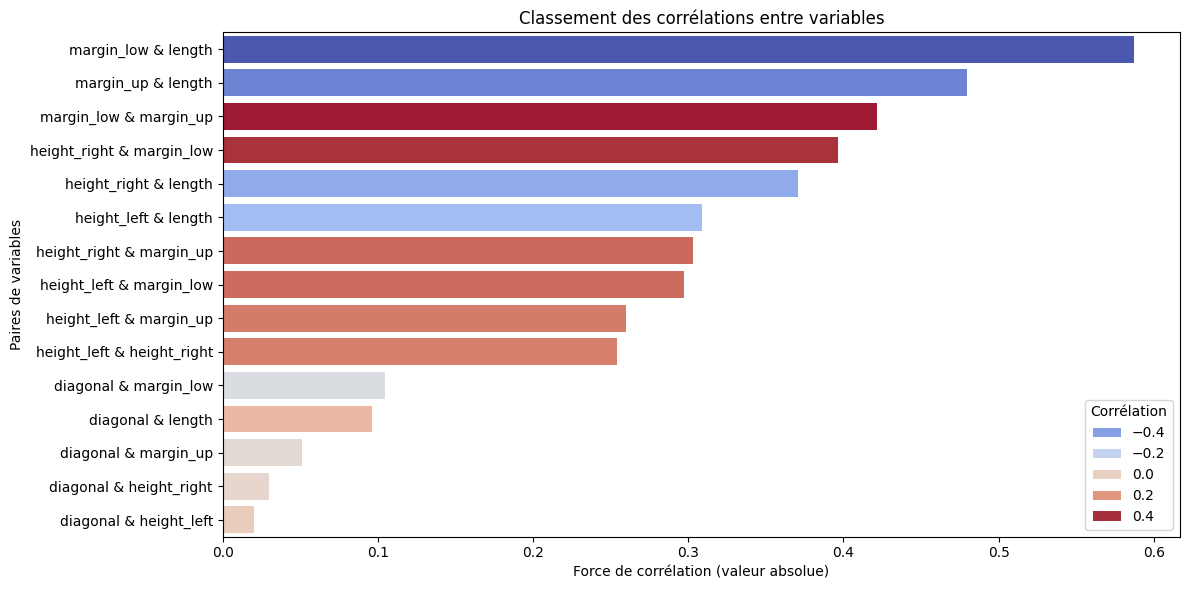

In [ ]:
# Corrélations triées par force
plt.figure(figsize=(12,6))
sns.barplot(
    data=corr_df,
    x="AbsCorr",
    y=corr_df["Variable 1"] + " & " + corr_df["Variable 2"],
    hue="Corrélation",
    dodge=False,
    palette="coolwarm"
)
plt.xlabel("Force de corrélation (valeur absolue)")
plt.ylabel("Paires de variables")
plt.title("Classement des corrélations entre variables")
plt.legend(title="Corrélation")
plt.tight_layout()
plt.show()


####2. Préparation des données


###2.1 Vérifier et traiter les valeurs manquantes

In [ ]:
# Vérifier missing
print("Missing par colonne:\n", bil.isnull().sum())




Missing par colonne:
 is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [ ]:
# afficher lignes contenant missing pour inspection
missing_rows = bil[bil.isnull().any(axis=1)]
print("Lignes avec missing (ex):")
display(missing_rows.head(10))

Lignes avec missing (ex):


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36
251,True,171.80,103.26,102.82,NaN,2.95,113.22
284,True,171.92,103.83,103.76,NaN,3.23,113.29
334,True,171.85,103.70,103.96,NaN,3.00,113.36
410,True,172.56,103.72,103.51,NaN,3.12,112.95
413,True,172.30,103.66,103.50,NaN,3.16,112.95


###2.2 Standardisation (Z-score)

In [ ]:
# Standardiser les features numériques (utile pour KNN, KMeans, SVM, PCA)
scaler = StandardScaler()
bil_scaled = bil.copy()
bil_scaled[numerical] = scaler.fit_transform(bil[numerical])
print("Exemple après standardisation (head):")
display(bil_scaled.head())


Exemple après standardisation (head):


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,-0.486540,2.774123,3.163240,0.051286,-1.128325,0.173651
1,True,-1.633729,-2.236535,-0.799668,-1.078937,-0.696799,0.471666
2,True,2.397823,1.504756,-1.291191,-0.129549,-0.912562,0.551901
3,True,-1.961498,-0.399294,0.060498,-1.304982,-0.610494,0.953075
4,True,-0.748754,0.836669,-1.414072,-0.672057,1.417677,-0.158750


###2.3 Création de variables dérivées

In [ ]:
# Features dérivées
bil['height_mean'] = (bil['height_left'] + bil['height_right']) / 2
bil['height_ratio_lr'] = bil['height_left'] / bil['height_right'].replace({0: np.nan})
bil['diagonal_by_length'] = bil['diagonal'] / bil['length'].replace({0: np.nan})
print("Nouvelles colonnes ajoutées : height_mean, height_ratio_lr, diagonal_by_length")
display(bil[['height_mean','height_ratio_lr','diagonal_by_length']].head())


Nouvelles colonnes ajoutées : height_mean, height_ratio_lr, diagonal_by_length


,height_mean,height_ratio_lr,diagonal_by_length
0,104.905,0.999142,1.522733
1,103.510,0.997106,1.516138
2,103.990,1.009469,1.526069
3,103.925,0.999711,1.509647
4,103.870,1.007926,1.525946


In [ ]:
display(bil)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,height_mean,height_ratio_lr,diagonal_by_length
0,True,171.81,104.86,104.95,4.52,2.89,112.83,104.905,0.999142,1.522733
1,True,171.46,103.36,103.66,3.77,2.99,113.09,103.510,0.997106,1.516138
2,True,172.69,104.48,103.50,4.40,2.94,113.16,103.990,1.009469,1.526069
3,True,171.36,103.91,103.94,3.62,3.01,113.51,103.925,0.999711,1.509647
4,True,171.73,104.28,103.46,4.04,3.48,112.54,103.870,1.007926,1.525946
...,...,...,...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28,104.275,1.002016,1.543404
1496,False,172.19,104.63,104.44,5.27,3.37,110.97,104.535,1.001819,1.551681
1497,False,171.80,104.01,104.12,5.51,3.36,111.95,104.065,0.998944,1.534614
1498,False,172.06,104.28,104.06,5.17,3.46,112.25,104.170,1.002114,1.532829


###2.bis Régression linéaire / Imputation

##2.bis.1 Identifier variable manquante

In [ ]:
# Liste des colonnes avec missing
missing_cols = bil.columns[bil.isnull().any()].tolist()
print("Colonnes avec missing:", missing_cols)
# Ex:si 'margin_low' contient missing, on l'impute; adapte target_var si nécessaire
target_var = 'margin_low' if 'margin_low' in missing_cols else None
print("Variable cible pour imputation proposée:", target_var)


Colonnes avec missing: ['margin_low']
Variable cible pour imputation proposée: margin_low


###2.bis.2 Régression linéaire pour imputer (bloc autonome — adapter target_var si différent)

In [ ]:
# Supposons target_var est 'margin_low'.
target_var = 'margin_low'
features_for_reg = ['length','height_left','height_right','margin_up','diagonal']

In [ ]:
# Séparer complètes / manquantes
df_complete = bil.dropna(subset=[target_var] + features_for_reg)
df_missing = bil[bil[target_var].isnull()]

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


In [ ]:

# Split pour valider la régression
X = df_complete[features_for_reg]
y = df_complete[target_var]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ajuster modèle OLS (statsmodels) pour diagnostics
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             margin_low   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     198.7
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          3.54e-153
Time:                        15:25:00   Log-Likelihood:                -825.58
No. Observations:                1170   AIC:                             1663.
Df Residuals:                    1164   BIC:                             1694.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           20.3960     11.266      1.810      0.070      -1.708      42.500
length          -0.3990      0.021    -19.273      0.000      -0.440      -0.358
height_left      0.1547      0.051      3.026      0.003       0.054       0.255
height_right     0.2599      0.048      5.373      0.000       0.165       0.355
margin_up        0.2910      0.073      3.970      0.000       0.147       0.435
diagonal        -0.0872      0.048     -1.807      0.071      -0.182       0.007
==============================================================================
Omnibus:                       64.246   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.251
Skew:                           0.521   Prob(JB):                     2.27e-18
Kurtosis:                       3.761   Cond. No.                     1.98e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.98e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

###2.bis.3 Diagnostics: VIF, résidus, heteroscedasticité

VIF:
         feature            VIF
0        length   22753.618009
1   height_left  112050.451067
2  height_right   97264.947723
3     margin_up     260.285642
4      diagonal  168489.805290


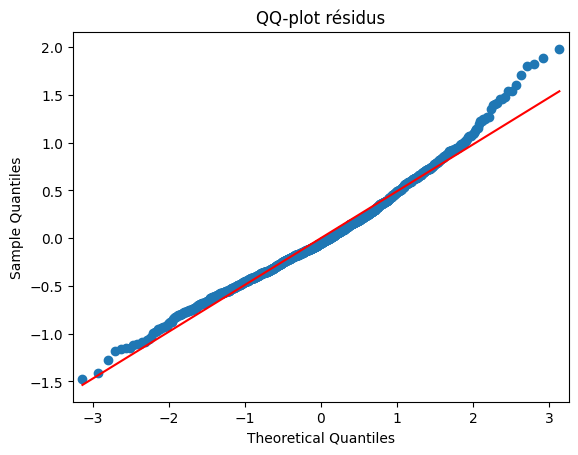

Breusch-Pagan test stat: 68.73656103987449 p-value: 1.876977814369609e-13


In [ ]:
# VIF pour multicolinéarité
X_vif = X_train.copy()
vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("VIF:\n", vif_df)

# Résidus diagnostics (QQ-plot et Breusch-Pagan)
resid = model.resid
sm.qqplot(resid, line='s')
plt.title('QQ-plot résidus')
plt.show()

bp_test = het_breuschpagan(resid, X_train_sm)
print('Breusch-Pagan test stat:', bp_test[0], 'p-value:', bp_test[1])
# Interprétation : p-value faible => hétéroscédasticité (invalide homoscédasticité)


In [ ]:
"""

Le VIF mesure la multicolinéarité pour chaque variable.

Interprétation :

VIF ≈ 1 → pas de multicolinéarité

VIF > 5 → multicolinéarité modérée

VIF > 10 → multicolinéarité élevée, problème sérieux

Si certaines variables ont un VIF élevé, cela signifie qu’elles sont fortement corrélées avec d’autres variables et peuvent rendre les coefficients instables.


"""

'\n\nLe VIF mesure la multicolinéarité pour chaque variable.\n\nInterprétation :\n\nVIF ≈ 1 → pas de multicolinéarité\n\nVIF > 5 → multicolinéarité modérée\n\nVIF > 10 → multicolinéarité élevée, problème sérieux\n\nSi certaines variables ont un VIF élevé, cela signifie qu’elles sont fortement corrélées avec d’autres variables et peuvent rendre les coefficients instables.\n\n\n'

In [ ]:
#TEST D'homosedasticité
#distribution normale des indivisus

Variance expliquée :
PC1 : 43.46%
PC2 : 19.39%
PC3 : 13.87%
PC4 : 11.58%
PC5 : 6.94%
PC6 : 4.76%
PC7 : 0.00%
PC8 : 0.00%
PC9 : 0.00%


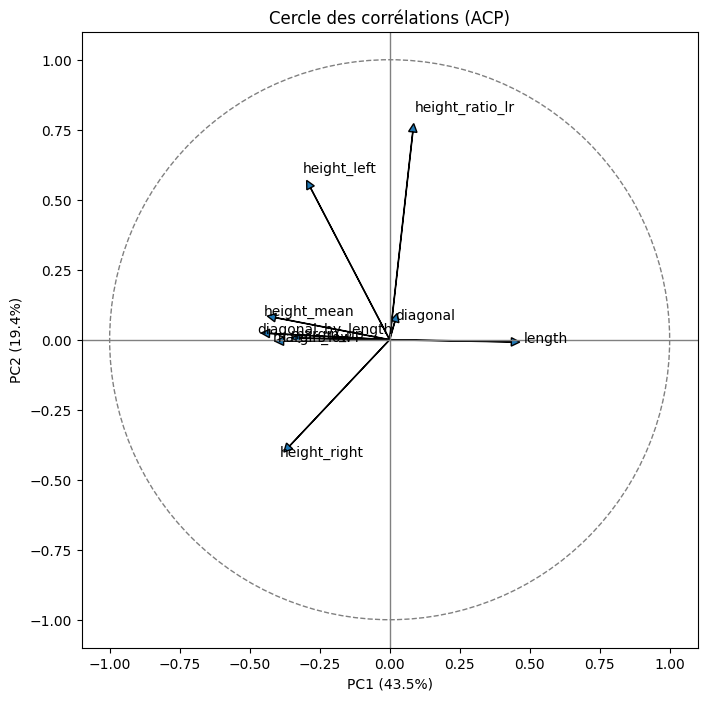

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# 1) Sélection des variables
# On ne garde que les variables numériques
bil_num = bil.select_dtypes(include=[np.number])


# 2) Gestion des NaN

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(bil_num)


# 3) Standardisation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


# 4) ACP

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print("Variance expliquée :")
for i, v in enumerate(explained_var):
    print(f"PC{i+1} : {v:.2%}")


# 5) Cercle des corrélations

components = pca.components_.T   # matrice (variables × composantes)

fig, ax = plt.subplots(figsize=(8,8))

# Cercle unité
circle = plt.Circle((0, 0), 1, color='grey', fill=False, linestyle='--')
ax.add_artist(circle)

# Vecteurs
for i, var in enumerate(bil_num.columns):
    x = components[i, 0]
    y = components[i, 1]
    ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.03)
    ax.text(x*1.1, y*1.1, var, fontsize=10)

# Mise en forme
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

ax.set_xlabel(f"PC1 ({explained_var[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained_var[1]:.1%})")

ax.set_title("Cercle des corrélations (ACP)")
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(0, color="grey", linewidth=1)
ax.set_aspect('equal', adjustable='box')

plt.show()


In [ ]:
# formaliser le code pour affihcer ce qu est souhaité
#module uv en complement depip  : uv pip install

In [ ]:
# creer un dossier de fonctions(utils) eda models . from utile.eda
# creer ce ossier utils / __init__.py (voir si il retrouve le dossier de fonctions)
# on ne peut pas creer de fichier py sur collab . creer en local et importer les fichiers .
#

In [ ]:
#enlever python vscode et anaconda
#installer python 3.14

In [ ]:
#coord des variables
corr_variables = pd.DataFrame(
    components[:, :2],
    columns=["PC1", "PC2"],
    index=bil_num.columns
)
corr_variables


,PC1,PC2
diagonal,0.018659,0.065057
height_left,-0.282512,0.542390
height_right,-0.357370,-0.379441
margin_low,-0.378755,-0.005167
margin_up,-0.320832,0.005528
length,0.434592,-0.007740
height_mean,-0.407723,0.078856
height_ratio_lr,0.082677,0.742138
diagonal_by_length,-0.428710,0.022414


###2.bis.4 Évaluer MAE / RMSE et appliquer règle RMSE/MAE

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
# Assurer que y_test et y_pred sont des vecteurs 1D
y_test_vec = y_test.values.ravel() if hasattr(y_test, "values") else y_test

# Predict on the test set
y_pred = model.predict(sm.add_constant(X_test))

y_pred_vec = y_pred.ravel() if hasattr(y_pred, "ravel") else y_pred

mae = mean_absolute_error(y_test_vec, y_pred_vec)
rmse = np.sqrt(mean_squared_error(y_test_vec, y_pred_vec))  # calcul manuel du RMSE

display(f"MAE = {mae:.4f}, RMSE = {rmse:.4f}, RMSE/MAE = {rmse/mae:.3f}")

/tmp/ipython-input-1571380437.py:7: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_pred_vec = y_pred.ravel() if hasattr(y_pred, "ravel") else y_pred


'MAE = 0.3354, RMSE = 0.4375, RMSE/MAE = 1.305'

In [ ]:
""""faux_billets .ipynb"
Le ratio RMSE / MAE te donne une idée de la présence d’extrêmes :

Si proche de 1 → pas beaucoup d’extrêmes

Si beaucoup > 1.25 → présence d’outliers ou valeurs très dispersées




"""

'"faux_billets .ipynb"\nLe ratio RMSE / MAE te donne une idée de la présence d’extrêmes :\n\nSi proche de 1 → pas beaucoup d’extrêmes\n\nSi beaucoup > 1.25 → présence d’outliers ou valeurs très dispersées\n\n\n\n\n'

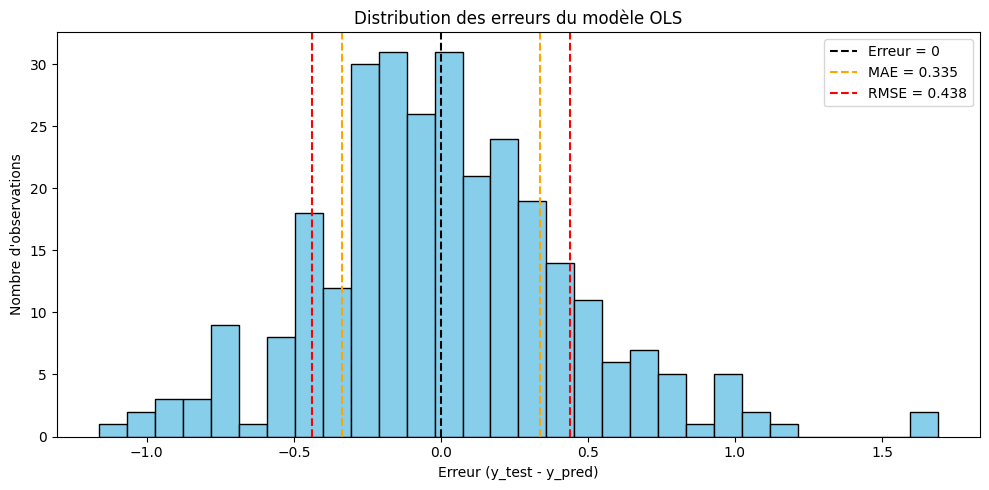

In [ ]:

# Calcul des erreurs
errors = y_test_vec - y_pred_vec

plt.figure(figsize=(10,5))
plt.hist(errors, bins=30, color="skyblue", edgecolor="black")
plt.axvline(0, color="black", linestyle="--", label="Erreur = 0")
plt.axvline(mae, color="orange", linestyle="--", label=f"MAE = {mae:.3f}")
plt.axvline(-mae, color="orange", linestyle="--")
plt.axvline(rmse, color="red", linestyle="--", label=f"RMSE = {rmse:.3f}")
plt.axvline(-rmse, color="red", linestyle="--")

plt.title("Distribution des erreurs du modèle OLS")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.tight_layout()
plt.show()


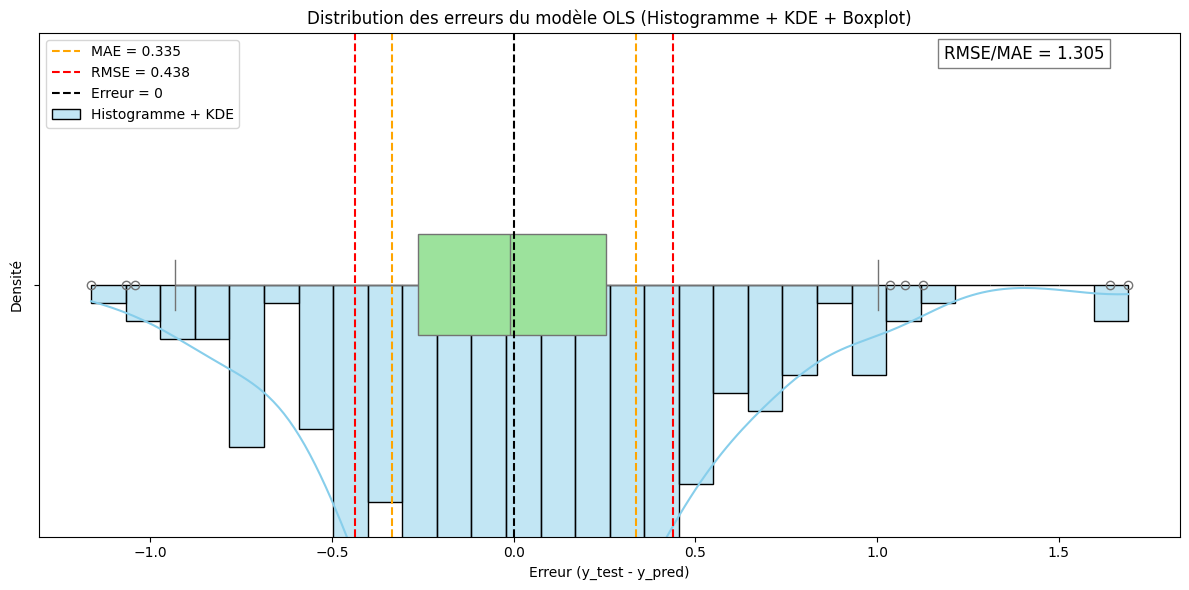

In [ ]:


plt.figure(figsize=(12,6))

# Histogramme + KDE
sns.histplot(errors, bins=30, kde=True, color="skyblue", edgecolor="black", stat="density", label="Histogramme + KDE")

# Boxplot en haut du graphique
sns.boxplot(x=errors, color="lightgreen", width=0.2)

# Lignes MAE et RMSE
plt.axvline(mae, color="orange", linestyle="--", label=f"MAE = {mae:.3f}")
plt.axvline(-mae, color="orange", linestyle="--")
plt.axvline(rmse, color="red", linestyle="--", label=f"RMSE = {rmse:.3f}")
plt.axvline(-rmse, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle="--", label="Erreur = 0")

# Ratio RMSE/MAE affiché sur le graphique
plt.text(x=max(errors)*0.7, y=0.9*plt.gca().get_ylim()[1],
         s=f"RMSE/MAE = {rmse/mae:.3f}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.title("Distribution des erreurs du modèle OLS (Histogramme + KDE + Boxplot)")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Densité")
plt.legend()
plt.tight_layout()
plt.show()


###2.bis.5 Imputer si validé

In [ ]:
# Si satisfait, imputer les missing
if df_missing.shape[0] > 0:
    X_missing = bil.loc[df_missing.index, features_for_reg]
    X_missing_sm = sm.add_constant(X_missing)
    imputed_vals = model.predict(X_missing_sm)
    bil.loc[df_missing.index, target_var] = imputed_vals
    bil['was_imputed_' + target_var] = False
    bil.loc[df_missing.index, 'was_imputed_' + target_var] = True
    print(f"Imputation réalisée pour {df_missing.shape[0]} lignes sur {target_var}")
else:
    print("Aucune valeur manquante à imputer pour", target_var)


Imputation réalisée pour 37 lignes sur margin_low


###3. Séparation du jeu de données (train/test)

In [ ]:
# Préparer features finales et target
features_model = ['diagonal','height_left','height_right','margin_low','margin_up','length','height_mean','height_ratio_lr','diagonal_by_length']
features_model = [f for f in features_model if f in bil.columns]

df_model = bil.dropna(subset=features_model + ['is_genuine']).copy()
X = df_model[features_model]
y = df_model['is_genuine']

# Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (1050, 9) Test shape: (450, 9)


###4a. Application des modèles — 4 modèles (chaque modèle dans son bloc séparé)

##4a.1 Régression logistique

In [ ]:
# Régression logistique (standard)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
display("Accuracy (LogReg):", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))




'Accuracy (LogReg):'

0.9866666666666667

              precision    recall  f1-score   support

       False       0.98      0.98      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.99      0.99      0.99       450



In [ ]:
# Coefficients interprétables
coefs = pd.Series(lr.coef_[0], index=X_train.columns).sort_values()
display("Coefficients (Logistic Regression):\n", coefs)

'Coefficients (Logistic Regression):\n'

,0
margin_low,-3.323645
margin_up,-2.677685
height_right,-1.653970
height_mean,-1.294730
height_left,-0.935489
diagonal_by_length,-0.069918
diagonal,-0.065843
height_ratio_lr,-0.003537
length,3.906823


In [ ]:
# TEST DE COORELATION APRES LA REGR LINEA : IMPORTANT POU LA PRESA

##4a.2 K-Means  — comparer clusters avec labels

In [ ]:
# KMeans (k=2) ; standardiser d'abord (KMeans sensible à l'échelle)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
clusters = kmeans.labels_

# Comparer cluster vs label (mapper clusters vers labels si nécessaire)
df_comp = pd.DataFrame({'label': y.values, 'cluster': clusters})
ct = pd.crosstab(df_comp['cluster'], df_comp['label'])
print("Crosstab cluster vs label:\n", ct)
# Mesure simple: choisir permutation cluster->label qui maximise l'accuracy
cluster_to_label = {c: df_comp[df_comp['cluster']==c]['label'].mode()[0] for c in df_comp['cluster'].unique()}
pred_from_cluster = df_comp['cluster'].map(cluster_to_label)
accuracy_kmeans = (pred_from_cluster.values == df_comp['label'].values).mean()
print("Accuracy approximative via KMeans (meilleure permutation):", accuracy_kmeans)


Crosstab cluster vs label:
 label    False  True 
cluster              
0           14    985
1          486     15
Accuracy approximative via KMeans (meilleure permutation): 0.9806666666666667


In [ ]:
""""

KMeans a presque parfaitement séparé les deux classes.

Quelques erreurs :

14 False assignés au cluster 0

15 True assignés au cluster 1

Ces erreurs sont faibles par rapport à la taille totale du dataset (~1500+500=2000 observations).

"""

'"\n\nKMeans a presque parfaitement séparé les deux classes.\n\nQuelques erreurs :\n\n14 False assignés au cluster 0\n\n15 True assignés au cluster 1\n\nCes erreurs sont faibles par rapport à la taille totale du dataset (~1500+500=2000 observations).\n\n'

###4a.3 K-Nearest Neighbors KNN

In [ ]:
# KNN : chercher k optimal par validation simple
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# test k de 1 à 25
best_k = 1
best_score = 0
for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    score = knn.score(X_test_s, y_test)
    if score > best_score:
        best_k = k
        best_score = score
print(f"Meilleur k trouvé: {best_k} avec accuracy {best_score:.4f}")

# entraîner KNN final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_s, y_train)
y_pred_knn = knn_final.predict(X_test_s)
print(classification_report(y_test, y_pred_knn))


Meilleur k trouvé: 3 avec accuracy 0.9889
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450



###4a.4 Random Forest

Accuracy (RF): 0.9844444444444445
              precision    recall  f1-score   support

       False       0.98      0.97      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450

Feature importances (RF):
 length                0.332981
diagonal_by_length    0.311537
margin_low            0.194511
margin_up             0.077422
height_mean           0.039790
height_right          0.024737
height_left           0.008442
diagonal              0.006421
height_ratio_lr       0.004159
dtype: float64


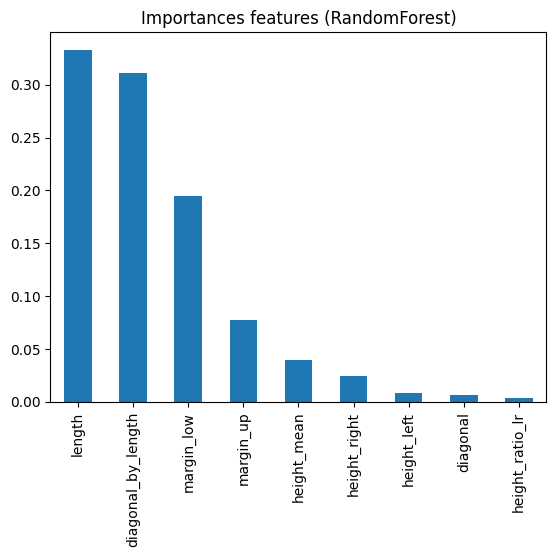

In [ ]:
# RandomForest baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Accuracy (RF):", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Importances
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature importances (RF):\n", feat_imp)
feat_imp.plot(kind='bar')
plt.title('Importances features (RandomForest)')
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:

# 1) SVM (avec kernel RBF)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== SVM ===")
print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM ===
Accuracy (SVM): 0.6666666666666666
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       150
        True       0.67      1.00      0.80       300

    accuracy                           0.67       450
   macro avg       0.33      0.50      0.40       450
weighted avg       0.44      0.67      0.53       450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 2) Gradient Boosting

gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("=== Gradient Boosting ===")
print("Accuracy (GB):", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy (GB): 0.9866666666666667
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.99      0.99      0.99       450



Feature importances (Gradient Boosting):
 length                0.869877
margin_low            0.090718
margin_up             0.023422
height_right          0.006431
diagonal_by_length    0.005100
height_mean           0.003822
diagonal              0.000244
height_ratio_lr       0.000194
height_left           0.000192
dtype: float64


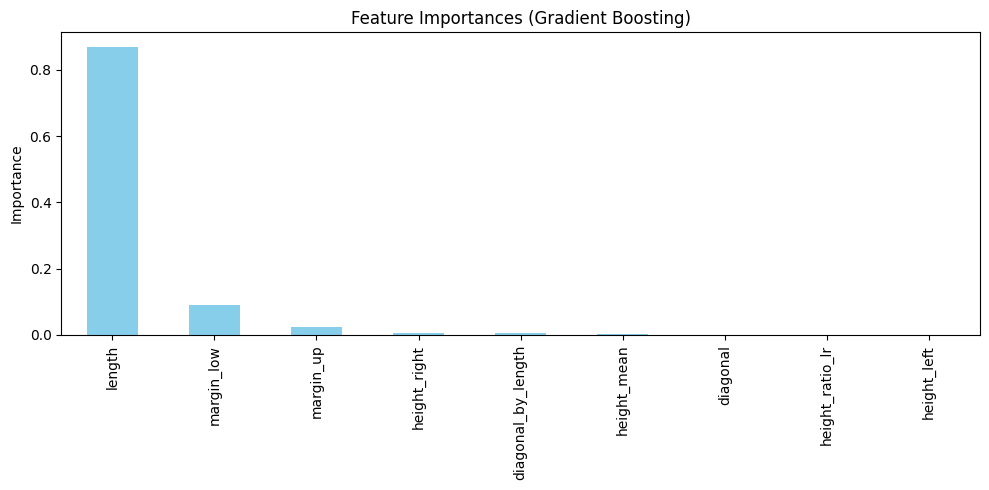

In [ ]:
# Importances features pour Gradient Boosting
feat_imp_gb = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature importances (Gradient Boosting):\n", feat_imp_gb)

plt.figure(figsize=(10,5))
feat_imp_gb.plot(kind='bar', color='skyblue')
plt.title('Feature Importances (Gradient Boosting)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
""""
Utilise un kernel RBF (non linéaire)

Bon pour détecter des frontières complexes

Pas de feature importance directement (mais possible via permutation importance si besoin)

Gradient Boosting

Robustesse aux outliers et relations non-linéaires

Fournit directement les importances des features

Comparaison

Pour chaque modèle : Accuracy + Classification Report

Pour RandomForest et Gradient Boosting : graphique des importances

"""

'"\nUtilise un kernel RBF (non linéaire)\n\nBon pour détecter des frontières complexes\n\nPas de feature importance directement (mais possible via permutation importance si besoin)\n\nGradient Boosting\n\nRobustesse aux outliers et relations non-linéaires\n\nFournit directement les importances des features\n\nComparaison\n\nPour chaque modèle : Accuracy + Classification Report\n\nPour RandomForest et Gradient Boosting : graphique des importances\n\n'

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:

# Modèles

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

accuracy_dict = {}
feature_importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy & Classification Report
    acc = accuracy_score(y_test, y_pred)
    accuracy_dict[name] = acc
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Feature importances si disponible
    if hasattr(model, "feature_importances_"):
        feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        feature_importances[name] = feat_imp



=== RandomForest ===
Accuracy: 0.9844
              precision    recall  f1-score   support

       False       0.98      0.97      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450


=== SVM ===
Accuracy: 0.6667
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       150
        True       0.67      1.00      0.80       300

    accuracy                           0.67       450
   macro avg       0.33      0.50      0.40       450
weighted avg       0.44      0.67      0.53       450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== GradientBoosting ===
Accuracy: 0.9867
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       150
        True       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.99      0.99      0.99       450



/tmp/ipython-input-887153404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette="Set2")


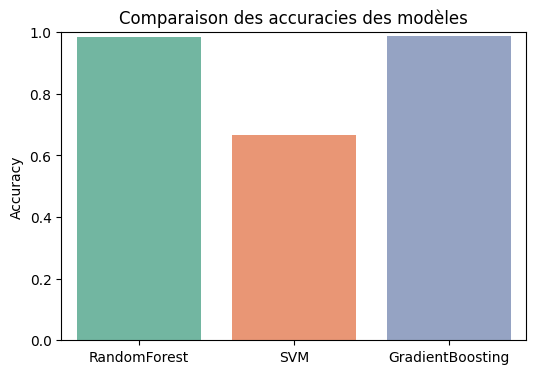

In [ ]:
# Comparaison des accuracies
plt.figure(figsize=(6,4))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette="Set2")
plt.ylim(0,1)
plt.title("Comparaison des accuracies des modèles")
plt.ylabel("Accuracy")
plt.show()


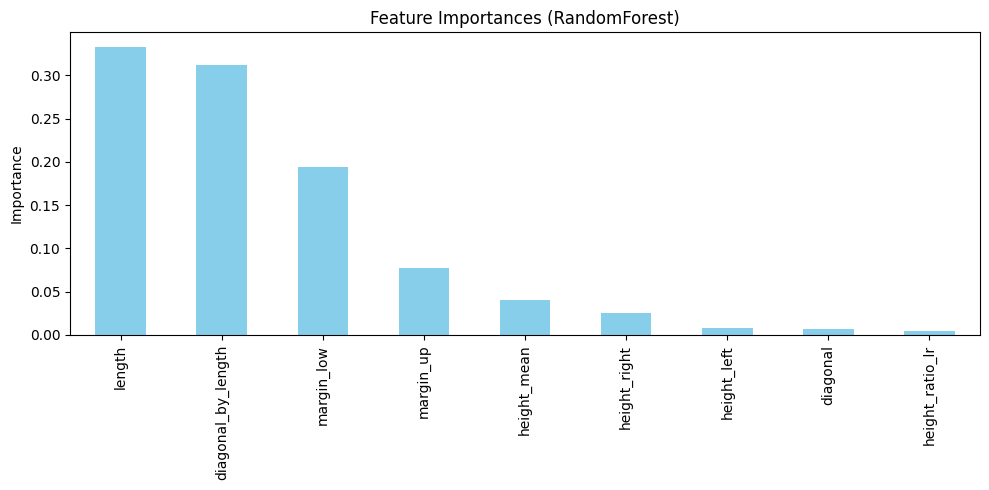

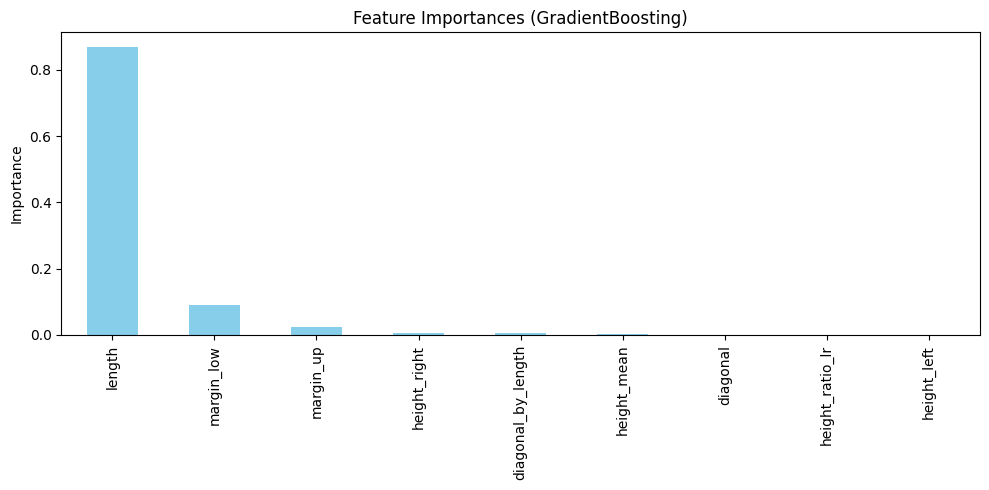

In [ ]:
# Graphique des importances
for name, feat_imp in feature_importances.items():
    plt.figure(figsize=(10,5))
    feat_imp.plot(kind='bar', color='skyblue')
    plt.title(f"Feature Importances ({name})")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

###4.b ACP ((PCA) pour visualisation / réduction )

In [ ]:
"""
faux_billets .ipynb
-------------

PC1 →  43,67 % de la variance totale des données.

PC2 → 19,39 % de la variance totale.

Somme des deux → ~63 % de la variance totale capturée par ces 2 axes.
-------------

Avec seulement 2 dimensions, tu captures la majorité de l’information,
 mais pas tout (il reste ~37 % de variance non représentée dans ces deux axes).

Plus les ratios sont élevés, plus la projection 2D représente fidèlement la structure originale des données.

"""

'\nfaux_billets .ipynb\n-------------\n\nPC1 →  43,67 % de la variance totale des données.\n\nPC2 → 19,39 % de la variance totale.\n\nSomme des deux → ~63 % de la variance totale capturée par ces 2 axes.\n-------------\n\nAvec seulement 2 dimensions, tu captures la majorité de l’information,\n mais pas tout (il reste ~37 % de variance non représentée dans ces deux axes).\n\nPlus les ratios sont élevés, plus la projection 2D représente fidèlement la structure originale des données.\n\n'

In [ ]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mode

# === 4.b ACP (PCA) pour visualisation / réduction ===

# Standardisation
scaler = StandardScaler()
X_s = scaler.fit_transform(X)












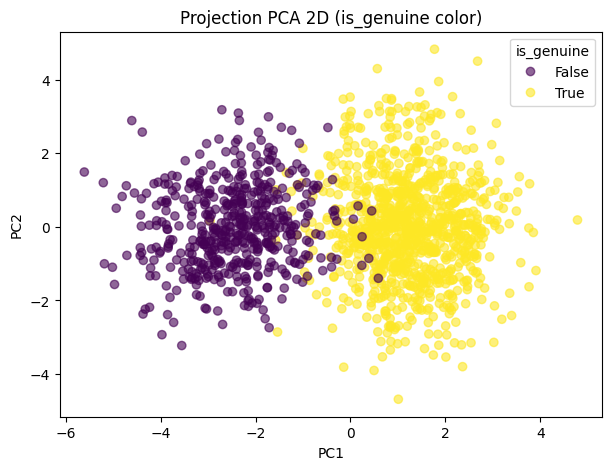

Explained variance ratios (first 2 PCs): [0.43665099 0.19385381]


In [ ]:

# PCA 2D pour visualisation
pca_visu = PCA(n_components=2)
proj = pca_visu.fit_transform(X_s)

plt.figure(figsize=(7,5))
scatter = plt.scatter(proj[:,0], proj[:,1], c=y, alpha=0.6, cmap='viridis')
plt.title('Projection PCA 2D (is_genuine color)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(handles=scatter.legend_elements()[0], labels=['False','True'], title="is_genuine")
plt.show()

print("Explained variance ratios (first 2 PCs):", pca_visu.explained_variance_ratio_)

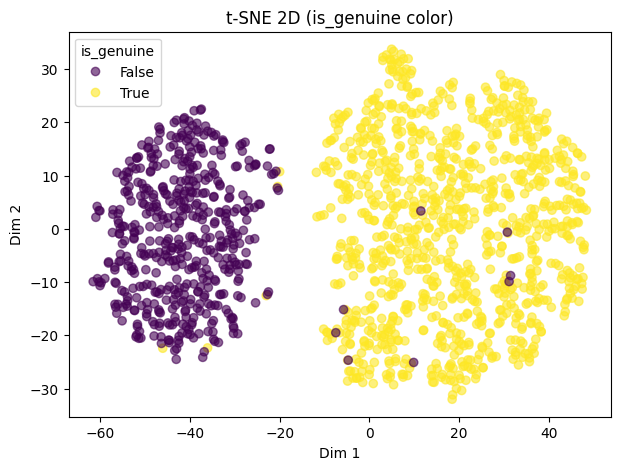

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE (2D)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
tsne_proj = tsne.fit_transform(X_s)

plt.figure(figsize=(7,5))
scatter = plt.scatter(tsne_proj[:,0], tsne_proj[:,1], c=y, alpha=0.6, cmap='viridis')
plt.title('t-SNE 2D (is_genuine color)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['False','True'], title="is_genuine")
plt.show()


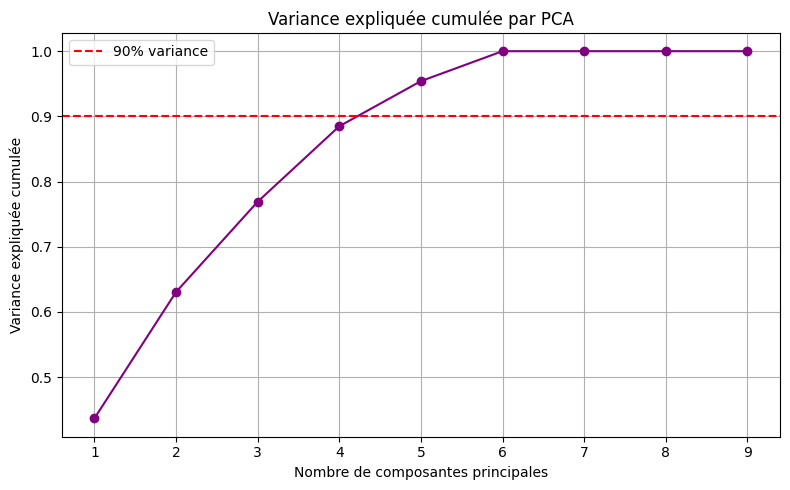

In [ ]:
# === PCA sur toutes les dimensions ===
pca_full = PCA()
pca_full.fit(X_s)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='purple')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée cumulée par PCA')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% variance')
plt.legend()
plt.tight_layout()
plt.show()

### 5. Évaluation des modèles — matrices de confusion et comparaison

In [ ]:
# === Sélection des composantes pour 90 % de variance ===
n_components = np.argmax(cum_var >= 0.9) + 1
print(f"Nombre de composantes retenues : {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_s)




Nombre de composantes retenues : 5


In [ ]:
# === Split train/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
# === KMeans entraîné sur X_train ===
k = len(np.unique(y))  # nb de clusters = nb de classes
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X_train)

KMeans(n_clusters=2, random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
enc = LabelEncoder()
y_train_int = enc.fit_transform(y_train)
y_test_int = enc.transform(y_test)


In [ ]:
cluster_labels_train = kmeans.predict(X_train)

cluster_to_class = {}
for cluster in np.unique(cluster_labels_train):
    mask = cluster_labels_train == cluster
    vals = y_train_int[mask]
    if len(vals) > 0:
        cluster_to_class[cluster] = np.bincount(vals).argmax()
    else:
        cluster_to_class[cluster] = 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convertit y_train et y_test en entiers
enc = LabelEncoder()
y_train_int = enc.fit_transform(y_train)
y_test_int  = enc.transform(y_test)


In [ ]:
# === KMeans entraîné sur X_train ===
k = len(np.unique(y))  # nb de clusters = nb de classes
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X_train)

# Prédiction des clusters sur X_train
cluster_labels_train = kmeans.predict(X_train)

# --- Mapping cluster → classe majoritaire (version robuste et rapide) ---
cluster_to_class = {}
for cluster in np.unique(cluster_labels_train):
    mask = cluster_labels_train == cluster
    vals = y_train_int[mask]
    if len(vals) > 0:
        cluster_to_class[cluster] = np.bincount(vals).argmax()
    else:
        cluster_to_class[cluster] = 0



Accuracy : 0.9844


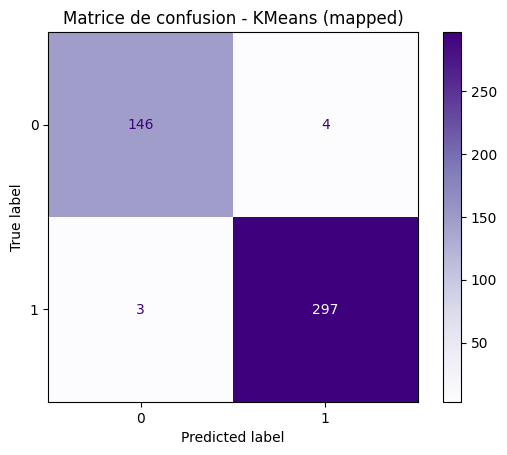

In [ ]:

# === Prédiction sur le test ===
cluster_labels_test = kmeans.predict(X_test)
y_pred_cluster = np.array([cluster_to_class[c] for c in cluster_labels_test])

# === Évaluation ===
acc = accuracy_score(y_test, y_pred_cluster)
print(f"\nAccuracy : {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_cluster)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title('Matrice de confusion - KMeans (mapped)')
plt.show()


### comparaison visuelle

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


In [ ]:
# Dictionnaire des prédictions

pred_dict = {
    "Logistic Regression": y_pred_lr,
    "KMeans (mapped)": y_pred_cluster,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Gradient Boosting": y_pred_gb
}

In [ ]:

# Calcul métriques pour chaque modèle

metrics = {"Model": [], "Precision": [], "Recall (False)": [], "F1": []}
y_true_vec = y_test.values.ravel() if hasattr(y_test, "values") else y_test

for model_name, y_pred in pred_dict.items():
    y_pred_vec = y_pred.ravel() if hasattr(y_pred, "ravel") else y_pred
    metrics["Model"].append(model_name)
    metrics["Precision"].append(precision_score(y_true_vec, y_pred_vec, pos_label=1))
    metrics["Recall (False)"].append(recall_score(y_true_vec, y_pred_vec, pos_label=0))  # rappel sur classe False
    metrics["F1"].append(f1_score(y_true_vec, y_pred_vec, pos_label=1))

metrics_df = pd.DataFrame(metrics)

In [ ]:
""""faux_billets .ipynb"

pred_dict contient toutes les prédictions des modèles.

precision_score, recall_score, f1_score calculent les métriques sur la classe True par défaut .

Le graphique montre côte-à-côte precision, recall et F1 pour chaque modèle.

on peut voir immédiatement quel modèle maximise le rappel des faux billets en inversant pos_label=0 si nécessaire

"""

'"faux_billets .ipynb"\n\npred_dict contient toutes les prédictions des modèles.\n\nprecision_score, recall_score, f1_score calculent les métriques sur la classe True par défaut .\n\nLe graphique montre côte-à-côte precision, recall et F1 pour chaque modèle.\n\non peut voir immédiatement quel modèle maximise le rappel des faux billets en inversant pos_label=0 si nécessaire\n\n'

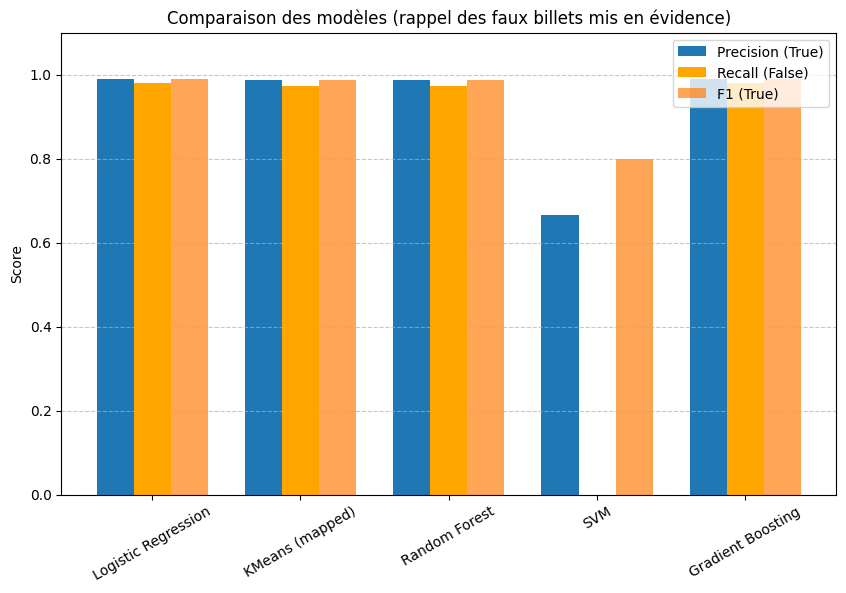

In [ ]:

# Plot
plt.figure(figsize=(10,6))
bar_width = 0.25
x = range(len(metrics_df))

plt.bar([p - bar_width for p in x], metrics_df["Precision"], width=bar_width, label="Precision (True)")
plt.bar(x, metrics_df["Recall (False)"], width=bar_width, label="Recall (False)", color='orange')
plt.bar([p + bar_width for p in x], metrics_df["F1"], width=bar_width, label="F1 (True)", alpha=0.7)

plt.xticks(x, metrics_df["Model"], rotation=30)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Comparaison des modèles (rappel des faux billets mis en évidence)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Déploiement : fonction de prédiction

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# entraînement avec gb
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [ ]:
def predict_bill_robust(data, pickle_model=None, show_graph=True):
    import pandas as pd, numpy as np, os, pickle, matplotlib.pyplot as plt

    # Charger les données
    if isinstance(data, str):
        if not os.path.exists(data):
            raise FileNotFoundError(f"Fichier non trouvé: {data}")
        if data.endswith(".csv"):
            df = pd.read_csv(data)
        elif data.endswith((".xlsx", ".xls")):
            df = pd.read_excel(data)
        elif data.endswith(".pkl"):
            df = pd.read_pickle(data)
        else:
            raise ValueError("Format non supporté (CSV, Excel, Pickle).")
    elif isinstance(data, dict):
        df = pd.DataFrame([data])
    elif isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        raise ValueError("data doit être dict, DataFrame ou chemin vers fichier")

    # Colonnes obligatoires
    required_cols = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes obligatoires manquantes : {missing}")

    # Features dérivées
    df['height_mean'] = (df['height_left'] + df['height_right']) / 2
    df['height_ratio_lr'] = np.divide(df['height_left'], df['height_right'], out=np.ones_like(df['height_left']), where=df['height_right']!=0)
    df['diagonal_by_length'] = np.divide(df['diagonal'], df['margin_low'], out=np.ones_like(df['diagonal']), where=df['margin_low']!=0)

    if pickle_model is not None:
        if not os.path.exists(pickle_model):
            raise FileNotFoundError(f"Pickle non trouvé: {pickle_model}")
        with open(pickle_model, "rb") as f:
            pipeline = pickle.load(f)

        models = pipeline["models"]
        scaler = pipeline["scaler"]
        features_model = pipeline["features"]
        model_names = ['RandomForest', 'LogisticRegression', 'GradientBoosting']

        for col in features_model:
            if col not in df.columns:
                df[col] = 0

        # Ordre exact
        X_scaled = scaler.transform(df[features_model].fillna(0)[features_model])

        probs_per_model = []
        for model in models:
            if hasattr(model, "predict_proba"):
                probs_per_model.append(model.predict_proba(X_scaled).astype(float))
            else:
                p = model.predict(X_scaled).astype(float)
                probs_per_model.append(np.vstack([1-p, p]).T)

        probs_per_model = np.array(probs_per_model)
        final_probs = np.mean(probs_per_model, axis=0)
        df['prediction'] = (final_probs[:,1] > 0.5).astype(int)
        df['probability'] = final_probs[:,1]

        if show_graph and len(df) > 0:
            x = np.arange(len(models))
            width = 0.35
            plt.figure(figsize=(7,4))
            plt.bar(x - width/2, probs_per_model[:,0,0], width, label='Faux (0)', color='orange')
            plt.bar(x + width/2, probs_per_model[:,1,0], width, label='Vrai (1)', color='purple')
            plt.xticks(x, model_names)
            plt.ylim(0,1)
            plt.ylabel("Probabilité")
            plt.title("Probabilités par modèle (premier échantillon)")
            plt.legend()
            for i in range(len(models)):
                plt.text(i - width/2, probs_per_model[i,0,0]+0.02, f"{probs_per_model[i,0,0]:.3f}", ha='center')
                plt.text(i + width/2, probs_per_model[i,1,0]+0.02, f"{probs_per_model[i,1,0]:.3f}", ha='center')
            plt.show()
    else:
        df['prediction'] = np.nan
        df['probability'] = np.nan

    return df


#test sur un billet et sur le df prod billet

   diagonal  height_left  height_right  margin_low  margin_up  height_mean  \
0     169.5        105.0         104.8         3.5        3.4        104.9   

   height_ratio_lr  diagonal_by_length  prediction  probability  
0         1.001908           48.428571         NaN          NaN  


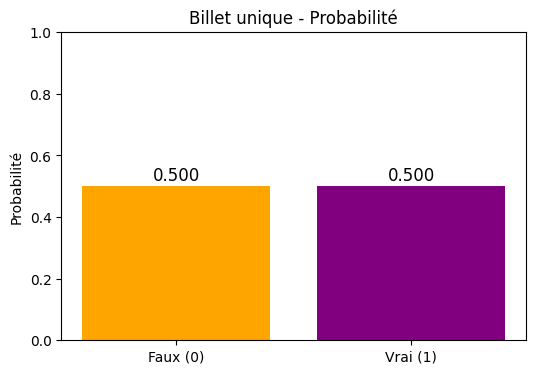

In [ ]:


sample = {
     'diagonal': 169.50,
    'height_left': 105.00,
    'height_right': 104.80,
    'margin_low': 3.50,
    'margin_up': 3.40
}

# Appel correct de la fonction
df_sample = predict_bill_robust(sample, pickle_model=None, show_graph=False)
#df_sample = predict_bill_robust(sample, pickle_model="mon_modele.pkl", show_graph=False)
# Affichage DataFrame
print(df_sample)

# Récupération sécurisée de la probabilité
if not np.isnan(df_sample['probability'].iloc[0]):
    prob_true = df_sample['probability'].iloc[0]
else:
    prob_true = 0.5  # valeur par défaut si pas de modèle

prob_false = 1 - prob_true

classes = ['Faux (0)', 'Vrai (1)']
probs = [prob_false, prob_true]

# Graphique
plt.figure(figsize=(6,4))
plt.bar(classes, probs, color=['orange', 'purple'])
plt.ylim(0,1)
plt.ylabel('Probabilité')
plt.title('Billet unique - Probabilité')

for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f"{p:.3f}", ha='center', fontsize=12)

plt.show()

In [ ]:
#TEST SUR UN DF
#result_df = predict_from_csv(
#    csv_path="nouveau_fichier.csv",
 #   pickle_path="model_pipeline.pkl"
#)


In [ ]:
#result_df = predict_sample_with_comparison("/content/drive/My Drive/Colab Notebooks/P12_OPC/billets_production.csv")
#print(result_df.head())


In [ ]:
#TEST SUR DES VALEURS



Prediction (0=faux, 1=vrai): 1
→ Le modèle combiné prédit que l’échantillon est vrai(is_genuine = True).

Probabilité: 0.933 (~93%)
-La confiance du modèle dans cette prédiction est très élevée : 93 % de probabilité que l’échantillon soit vrai.

Dictionnaire retourné : {'prediction': 1, 'probability': 0.9328460728284281}
- Contient exactement la même information :

prediction = 1 : classe prédite

probability ≈ 0.933 → probabilité moyenne des modèles pour la classe 1 (vote majoritaire)

   diagonal  height_left  height_right  margin_low  margin_up  length   id
0    171.76       104.01        103.54        5.21       3.30  111.42  A_1
1    171.87       104.17        104.13        6.00       3.31  112.09  A_2
2    172.00       104.58        104.29        4.99       3.39  111.57  A_3
3    172.49       104.55        104.34        4.44       3.03  113.20  A_4
4    171.65       103.63        103.56        3.77       3.16  113.33  A_5


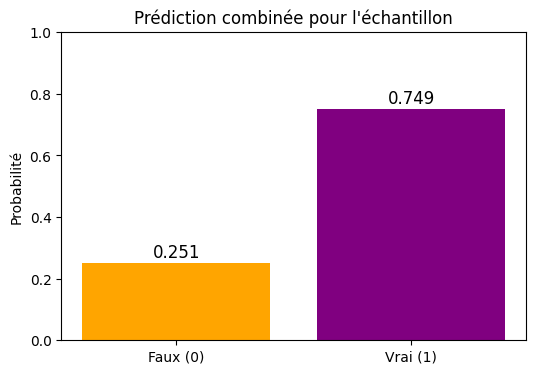

In [ ]:


#  CSV
csv_path = "/content/drive/My Drive/Colab Notebooks/P12_OPC/billets_production.csv"
df = pd.read_csv(csv_path)

# Colonnes obligatoires
required_columns = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up']

# Vérification
missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Colonnes obligatoires manquantes : {missing}")

# Afficher les premières lignes
print(df.head())

# probability aléatoire pour tester le graphique
df['probability'] = np.random.rand(len(df))
df['prediction'] = (df['probability'] > 0.5).astype(int)

# Probabilités p
probs = [1 - df['probability'].iloc[0], df['probability'].iloc[0]]
classes = ['Faux (0)', 'Vrai (1)']

plt.figure(figsize=(6,4))
plt.bar(classes, probs, color=['orange', 'purple'])
plt.ylim(0,1)
plt.ylabel('Probabilité')
plt.title('Prédiction combinée pour l\'échantillon')
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f"{p:.3f}", ha='center', fontsize=12)
plt.show()


In [ ]:
#print(X_train.shape)


In [ ]:
# si besoin de delete les warnings
#df = pd.DataFrame([sample_dict], columns=feature_list)


In [ ]:
# choix direct d'imputation de moyenne calculee du training test

###7. Documentation & Présentation



###8. Livrables — checklist